# Task 4 – Data Preprocessing & DataLoader
## Plant Disease Classification Project

### Objective:
Prepare the PlantVillage dataset for model training by applying transformations and creating PyTorch DataLoaders.

### Steps:
1. Define image transformations for training and validation.
2. Create PyTorch datasets.
3. Split data into training and validation sets.
4. Create DataLoaders.
5. Verify a batch of images.

In [1]:
# Import required libraries
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# Path to dataset
dataset_path = './dataset'

# Check if dataset exists
assert os.path.exists(dataset_path), "Dataset path does not exist!"

## 1. Define Image Transformations

We will apply resizing, augmentation for training, and normalization for both training and validation datasets.

In [2]:
# Define transformations
train_transforms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## 2. Create Dataset

We use `ImageFolder` to load images from folders. Each subfolder represents a class.

In [3]:
# Create dataset
full_dataset = datasets.ImageFolder(root=dataset_path, transform=train_transforms)

## 3. Split Dataset

We split the dataset into 80% training and 20% validation.

In [5]:
# Split dataset
val_size = int(0.2 * len(full_dataset))
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply validation transforms to val_dataset
val_dataset.dataset.transform = val_transforms

## 4. Create DataLoaders

We use `DataLoader` to batch and shuffle the data for training.

In [6]:
# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

## 5. Verify a Batch of Images

We take one batch from the training loader and visualize a few images to confirm preprocessing.

Batch shape: torch.Size([32, 3, 256, 256])
Labels shape: torch.Size([32])


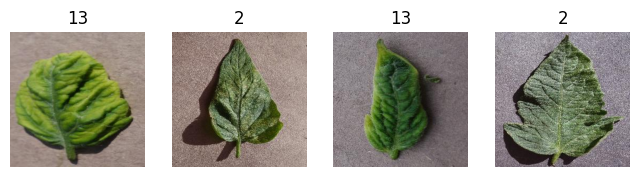

Data preprocessing completed successfully!


In [7]:
# Get one batch
images, labels = next(iter(train_loader))

print("Batch shape:", images.shape)
print("Labels shape:", labels.shape)

# Visualize 4 sample images
plt.figure(figsize=(8,4))
for i in range(4):
    img = images[i].permute(1,2,0)  # CHW → HWC
    img = img * torch.tensor([0.229,0.224,0.225]) + torch.tensor([0.485,0.456,0.406])  # Unnormalize
    img = torch.clamp(img, 0, 1)
    
    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.title(labels[i].item())
    plt.axis('off')
plt.show()

print("Data preprocessing completed successfully!")